In [25]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from statsmodels.stats.multitest import multipletests
# from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *
from mne_bids import BIDSPath, read_raw_bids
pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [26]:
subjects = ['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612']
bids_root = "/home1/maint/LTP_BIDS/"
exp = "valuecourier"

In [27]:
# get full events
full_evs = None
for sub in subjects:
    for session in range(6):
        try:
            bids_path = BIDSPath(
                subject=sub,
                session=str(session),
                task=exp,  
                datatype="beh",
                extension=".tsv",
                root=bids_root
            )
            evs = pd.read_csv(bids_path.fpath, sep="\t")
            full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
        except Exception as e:
            print(e)
full_evs
cols = ["primacybuf", "recencybuf", "serialpos"]

for c in cols:
    full_evs[c] = (
        pd.to_numeric(full_evs[c], errors="coerce")  # make sure it's numeric, NaNs stay NaN
        .astype("Int64")                             # pandas nullable integer dtype
    )

[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP607/ses-0/beh/sub-LTP607_ses-0_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP607/ses-1/beh/sub-LTP607_ses-1_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP607/ses-2/beh/sub-LTP607_ses-2_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP607/ses-3/beh/sub-LTP607_ses-3_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP607/ses-4/beh/sub-LTP607_ses-4_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP607/ses-5/beh/sub-LTP607_ses-5_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP609/ses-0/beh/sub-LTP609_ses-0_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP609/ses-1/beh/sub-LTP609_ses-1_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-

In [28]:
# Convert to DataFrame
value_recalls = full_evs[full_evs.trial_type == "VALUE_RECALL"] 
words = full_evs[full_evs.trial_type == "WORD"]
rec_words = full_evs[full_evs.trial_type == "REC_WORD"]
rec_vv_words = full_evs[full_evs.trial_type == "REC_WORD_VV"]

# WORD --> storepointtype, recalled--> VALUE_RECALL, REC_WORD, REC_WORD_VV
word_trial_to_storepointtype = words.set_index("trial")["storepointtype"].to_dict()
word_trial_to_recalled = words.set_index("trial")["recalled"].to_dict()
for event_type in ["VALUE_RECALL", "REC_WORD", "REC_WORD_VV"]:
    subset = full_evs[full_evs.trial_type == event_type]
    for idx, row in subset.iterrows():
        trial = row["trial"]
        if trial in word_trial_to_storepointtype:
            full_evs.at[idx, "storepointtype"] = word_trial_to_storepointtype[trial]
        if trial in word_trial_to_recalled:
            full_evs.at[idx, "recalled"] = word_trial_to_recalled[trial]

# VALUE_RECALL --> actualvalue, valuerecall --> WORD, `REC_WORD`, REC_WORD_VV
valuerecall_trial_to_actualvalue = value_recalls.set_index("trial")["actualvalue"].to_dict()
valuerecall_trial_to_valuerecall = value_recalls.set_index("trial")["valuerecall"].to_dict()

# --- Apply to multi-row event types ---
for event_type in ["WORD", "REC_WORD", "REC_WORD_VV"]:
    subset = full_evs[full_evs.trial_type == event_type]
    for idx, row in subset.iterrows():
        trial = row["trial"]

        # actualvalue
        if trial in valuerecall_trial_to_actualvalue:
            full_evs.at[idx, "actualvalue"] = valuerecall_trial_to_actualvalue[trial]

        # valuerecall
        if trial in valuerecall_trial_to_valuerecall:
            full_evs.at[idx, "valuerecall"] = valuerecall_trial_to_valuerecall[trial]

In [29]:
with open("all_items.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]
pool_map = {w: i+1 for i, w in enumerate(pool)}

full_evs["itemno"] = full_evs["item"].map(pool_map)

### Behavioral

In [30]:
# Overall recall probability

pres = full_evs.trial_type=='WORD'
recall_by_sub = full_evs[pres].groupby('subject')\
    .agg({'recalled':'mean'})\
    .rename(columns={"recalled":"Recall_Probability"}
)
recall_by_sub = recall_by_sub.reset_index()
recall_by_sub = recall_by_sub.sort_values(by="Recall_Probability", ascending=True)
sub_recall = recall_by_sub.subject.values
recall_by_sub

,subject,Recall_Probability
0,LTP606,0.24183


In [31]:
print(f"Mean = {recall_by_sub['Recall_Probability'].mean()}, SD = {recall_by_sub['Recall_Probability'].std()}")

Mean = 0.24183006535947713, SD = nan


In [32]:
# SPC

spc_df = full_evs.query("trial_type=='WORD'").groupby(
    ['subject', 'session', 'serialpos']
).agg({'recalled':np.nanmean}).reset_index()

avg_spc_df = spc_df.groupby(["subject","serialpos"]).agg({"recalled":"mean"}).reset_index()

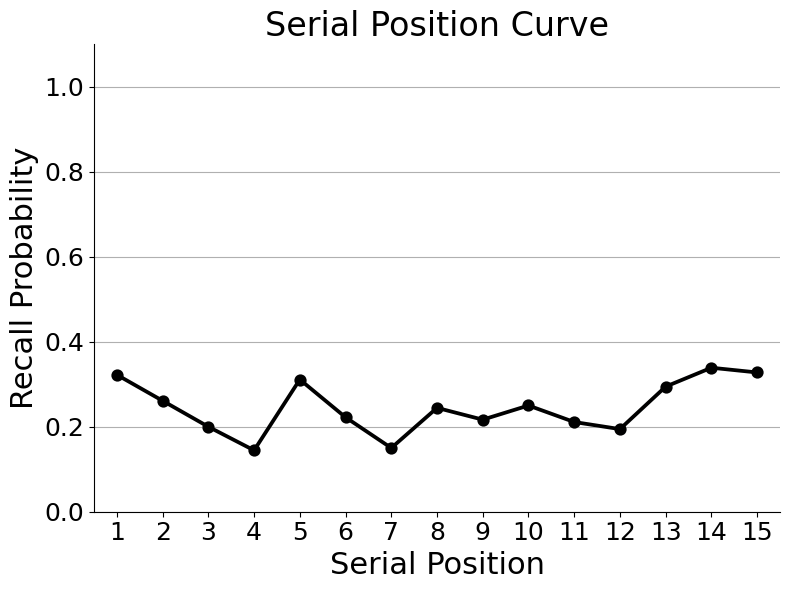

In [33]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = avg_spc_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='recalled', ci=None, ax=ax, color=colors[i])
    
spc = sns.pointplot(data=avg_spc_df, x='serialpos', y='recalled', ci=68, capsize=.3, ax=ax, color="k")

plt.title('Serial Position Curve', fontsize=24)
plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.1)
spc.yaxis.grid()
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
plt.show()

In [34]:
# for key, grp in first_recall_df.groupby(['subject', 'serialpos']):
#     print("\nGroup key:", key)
#     print(grp.head())


In [35]:
# recword = full_evs.query('trial_type=="REC_WORD"')
# recword['pos'] = recword.groupby(['subject', 'session', 'trial']).cumcount()
# mask = (recword['pos'] == 0) & recword['serialpos'].notna()
# first_recall_df = recword.loc[mask]
# first_recall_df.groupby(
#     ['subject', 'serialpos']).agg(
#     {'recalled': 'count'}).unstack(fill_value=0).stack().reset_index()


In [36]:
# Probability of first recall

recword = full_evs.query('trial_type=="REC_WORD"')
recword['pos'] = recword.groupby(['subject', 'session', 'trial']).cumcount()
first_recall_df = recword.query('pos == 0').query('serialpos.notnull()')
first_recall_df = first_recall_df.groupby(
    ['subject', 'serialpos']).agg(
    {'recalled': 'count'}).unstack(fill_value=0).stack().reset_index()
first_recall_df['n_lists'] = first_recall_df.groupby(['subject'])['recalled'].transform('sum')
first_recall_df['prob'] = first_recall_df['recalled'] / first_recall_df['n_lists']
first_recall_df

,subject,serialpos,recalled,n_lists,prob
0,LTP606,1,3,48,0.062500
1,LTP606,3,4,48,0.083333
2,LTP606,4,1,48,0.020833
3,LTP606,5,3,48,0.062500
4,LTP606,6,1,48,0.020833
5,LTP606,7,3,48,0.062500
6,LTP606,8,1,48,0.020833
7,LTP606,9,1,48,0.020833
8,LTP606,10,5,48,0.104167
9,LTP606,11,2,48,0.041667


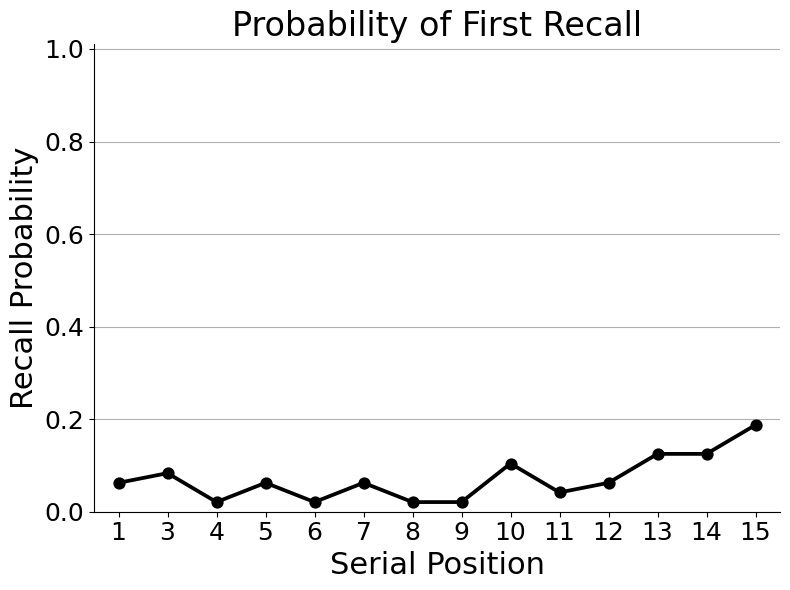

In [37]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = first_recall_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='prob', ci=None, ax=ax, color=colors[len(colors)-i-1])

spc = sns.pointplot(data=first_recall_df, x='serialpos', y='prob', ci=68, capsize=.3, ax=ax, color="k")

plt.title('Probability of First Recall', fontsize=24)
plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.01)
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
spc.yaxis.grid()
plt.show()

In [38]:
# Lag CRP

rec_word_types_all = ['REC_WORD', 'REC_WORD_VV']
present_types = set(full_evs['trial_type'].unique())
present_rec_types = [t for t in rec_word_types_all if t in present_types]

need_types = ['WORD'] + present_rec_types
clean_evs = full_evs[full_evs['trial_type'].isin(need_types)].copy()

for t in present_rec_types:
    if t != 'REC_WORD':
        clean_evs.loc[clean_evs['trial_type'] == t, 'trial_type'] = 'REC_WORD'

is_word = clean_evs['trial_type'].eq('WORD')
is_rec  = clean_evs['trial_type'].eq('REC_WORD')

temporal_evs = clean_evs[~(is_word & clean_evs['itemno'].isna())].copy()
temporal_evs.loc[is_rec, 'itemno'] = temporal_evs.loc[is_rec, 'itemno'].fillna(0)

temporal_evs['itemno'] = (
    pd.to_numeric(temporal_evs['itemno'], errors='coerce')
    .astype('Int64')  # note the capital I
)
temporal_evs

,mstime,trial_type,stim_file,actualvalue,compensation,eegfile,eogArtifact,experiment,intruded,intrusion,item,itemno,itemvalue,montage,msoffset,multiplier,numingroupchosen,phase,playerrotY,presX,presZ,primacybuf,protocol,recalled,rectime,recencybuf,serialpos,session,store,storeX,storeZ,storepointtype,subject,trial,valuerecall
68,2287892,WORD,wordpools/valuecourier_wordpool.txt,22.933332,8.461538,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,JEANS,115,10.0,0,-1,0.846154,4.0,1,84.570000,56.968750,81.750000,2,ltp,1.0,NaN,3,1,0,clothing_store,56.718750,77.937500,Temporal,LTP606,0,23.0
70,2352924,WORD,wordpools/valuecourier_wordpool.txt,22.933332,8.461538,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,WATER_GUN,232,13.0,0,-1,0.846154,4.0,1,103.199997,-33.375000,-83.812500,2,ltp,1.0,NaN,3,2,0,toy_store,-29.187500,-93.875000,Temporal,LTP606,0,23.0
71,2375559,WORD,wordpools/valuecourier_wordpool.txt,22.933332,8.461538,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,LIGHT,122,22.0,0,-1,0.846154,4.0,1,206.360001,22.296875,-51.375000,2,ltp,0.0,NaN,3,3,0,bike_shop,18.671875,-51.718750,Temporal,LTP606,0,23.0
73,2437993,WORD,wordpools/valuecourier_wordpool.txt,22.933332,8.461538,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,PEARLS,154,22.0,0,-1,0.846154,4.0,1,2.900000,-42.531250,61.000000,2,ltp,0.0,NaN,3,4,0,jewelry_store,-37.500000,61.000000,Temporal,LTP606,0,23.0
74,2454991,WORD,wordpools/valuecourier_wordpool.txt,22.933332,8.461538,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,NAILGUN,138,16.0,0,-1,0.846154,4.0,1,77.989998,-6.160156,125.750000,2,ltp,1.0,NaN,3,5,0,hardware_store,-8.867188,131.875000,Temporal,LTP606,0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,2530909,WORD,wordpools/valuecourier_wordpool.txt,10.133333,NaN,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,OREGANO,149,7.0,0,-1,NaN,4.0,1,352.640015,102.375000,51.843750,2,ltp,0.0,NaN,3,13,5,pizzeria,98.687500,51.812500,Temporal,LTP606,5,10.0
1703,2557592,WORD,wordpools/valuecourier_wordpool.txt,10.133333,NaN,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,SYRUP,212,16.0,0,-1,NaN,4.0,1,170.919998,-107.062500,-30.500000,2,ltp,0.0,NaN,3,14,5,cafe,-112.062500,-30.484375,Temporal,LTP606,5,10.0
1704,2577009,WORD,wordpools/valuecourier_wordpool.txt,10.133333,NaN,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,0.0,NaN,WATER_GUN,232,20.0,0,-1,NaN,4.0,1,219.110001,-34.843750,-83.875000,2,ltp,0.0,NaN,3,15,5,toy_store,-29.187500,-93.875000,Temporal,LTP606,5,10.0
1711,2623994,REC_WORD,wordpools/valuecourier_wordpool.txt,10.133333,NaN,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,NaN,0.0,ORCHIDS,148,NaN,0,20,NaN,NaN,1,NaN,-3.544922,9.984375,<NA>,ltp,0.0,3019.0,<NA>,4,5,florist,140.750000,60.593750,Temporal,LTP606,5,10.0


In [39]:

crp_df = temporal_evs.groupby(['subject']).apply(
    pb.pd_crp,
    itemno_column='itemno',
    list_index=['subject', 'session', 'trial'],
    lag_num=14,type_column="trial_type").reset_index()

In [40]:
crp_df

,subject,level_1,prob,lag
0,LTP606,-14,0.166667,-14
1,LTP606,-13,0.166667,-13
2,LTP606,-12,0.200000,-12
3,LTP606,-11,0.000000,-11
4,LTP606,-10,0.042553,-10
5,LTP606,-9,0.071429,-9
6,LTP606,-8,0.071429,-8
7,LTP606,-7,0.000000,-7
8,LTP606,-6,0.044776,-6
9,LTP606,-5,0.125000,-5


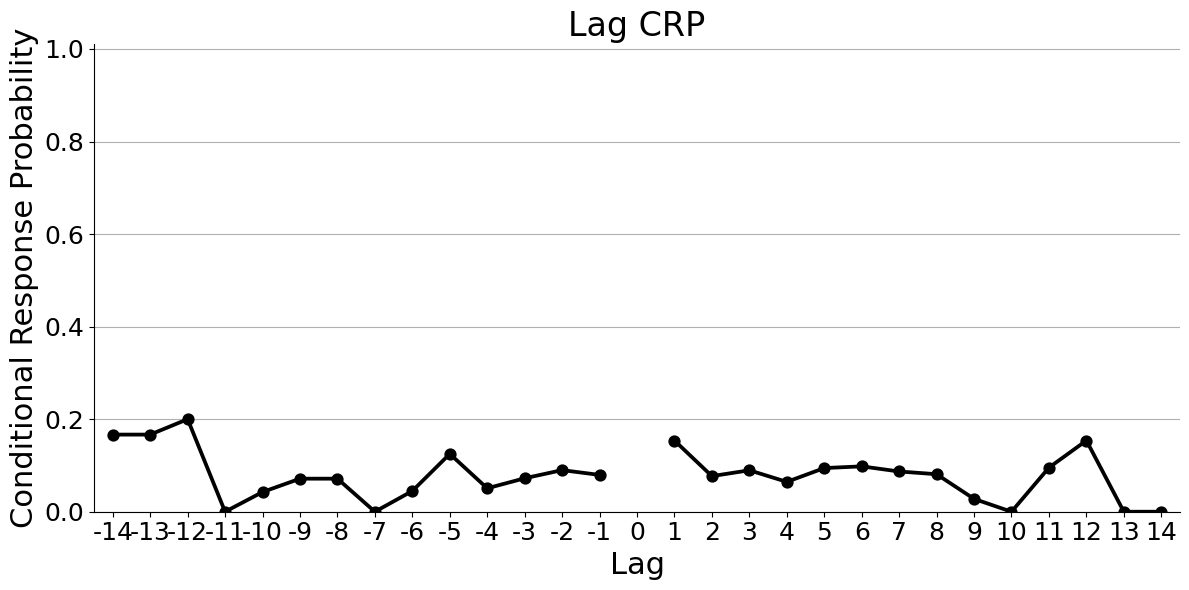

In [41]:
fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax = plt.gca()

from matplotlib.colors import ListedColormap

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_crp = crp_df.query('subject == @sub')
    sns.pointplot(data=sub_crp, x="lag", y="prob", 
                  color= colors[i], 
                  ax=ax,
                  linestyles="-")
 
crp = sns.pointplot(data=crp_df, x='lag', y='prob', ci=68,
                    color='k', capsize=.2, ax=ax)

ax.set_title('Lag CRP', fontsize=24)
ax.set_xlabel('Lag', fontsize=22)
ax.set_ylabel('Conditional Response Probability', fontsize=22)
ax.tick_params(labelsize=18)
plt.ylim([0,1.01])
ax.yaxis.grid()
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
# Temporal clustering score

temporal_clustering_df = compute_temporal_clustering(temporal_evs, type_column="type_trial")
temporal_clustering_df

,subject,TC
0,LTP606,0.527796


In [43]:
# Error plots

merged_df = get_mixed_model_fitted_error(temporal_evs, recall_by_sub,type_column="trial_type")
plot_error_diff_vs_binned_cluster_score(merged_df)

   subject  session  trial  actualvalue  valuerecall  item_count  \
0   LTP606        0      0    22.933332         23.0          15   
1   LTP606        0      1    16.933332         17.0          15   
2   LTP606        0      2    11.200000         11.0          15   
3   LTP606        0      3    32.000000         36.0          15   
4   LTP606        0      4    24.933332         24.0          15   
5   LTP606        1      0    22.933332         23.0          15   
6   LTP606        1      1    16.933332         17.0          15   
7   LTP606        1      2    11.200000         11.0          15   
8   LTP606        1      3    32.000000         36.0          15   
9   LTP606        1      4    24.933332         24.0          15   
10  LTP606        1      5    10.133333         10.0          15   
11  LTP606        1      6    30.000000         30.0          15   
12  LTP606        1      7    25.000000         25.0          15   
13  LTP606        1      8    10.133333         

LinAlgError: Singular matrix

In [ ]:
sub_error_df = get_mixed_model_fitted_error_conditions(temporal_evs)
sub_error_df

In [ ]:
plot_error_vs_cluster_score_conditions(sub_error_df)

In [ ]:
experiment = 'ValueCourier'
data = cml.get_data_index(kind = 'ltp')
data = data[(data['experiment']==experiment)].sort_values('session').reset_index()

full_evs = None
for i, row in data.iterrows():
    # intialize data reader, load words events and buffered eeg epochs
    r = cml.CMLReader(subject=row['subject'], experiment=row['experiment'], session=row['session'])
    evs = r.load('task_events')
    full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
full_evs = full_evs.query('subject in @subjects')
full_evs

In [ ]:
cml.CMLReader(subject="LTP606", experiment=experiment, session=3).load('task_events')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------------------
# 1. Trial-level errors → session-level mean error
# ---------------------------------------------------
error_by_trial = compute_trial_error_conditions(full_evs)

sub_error = (
    error_by_trial
    .groupby(['subject', 'session'], as_index=False)
    .agg(
        err_all=('error_all', 'mean'),
        err_middle=('error_middle', 'mean'),
        err_correct=('error_correct', 'mean'),
        err_corr_mid=('error_corr_mid', 'mean'),
    )
)

# ---------------------------------------------------
# 2. Compensation per subject × session
# ---------------------------------------------------
rows = []

for sub in subjects:
    for sess in range(6):
        subset = full_evs[(full_evs.subject == sub) & (full_evs.session == sess)]
        if subset.empty:
            continue

        comp = subset.iloc[0].compensation
        if comp >= 0:
            rows.append({"subject": sub, "session": sess, "compensation": comp})

df_comp = pd.DataFrame(rows).sort_values(["subject", "session"])

# ---------------------------------------------------
# 3. Merge compensation + error (use err_all)
# ---------------------------------------------------
df = pd.merge(df_comp, sub_error[["subject", "session", "err_all"]],
              on=["subject", "session"], how="inner")

# ---------------------------------------------------
# 4. REMOVE subjects with only 1 session
# ---------------------------------------------------
counts = df.groupby("subject")["session"].nunique()
subjects_keep = counts[counts > 1].index

df = df[df["subject"].isin(subjects_keep)]

print("Subjects kept (≥2 sessions):", list(subjects_keep))

# ---------------------------------------------------
# 5. Plot – twin axes: compensation vs mean error_all
# ---------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

subjects_plot = sorted(df["subject"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(subjects_plot)))

for color, sub in zip(colors, subjects_plot):
    df_sub = df[df["subject"] == sub].sort_values("session")

    # Left axis: compensation
    ax1.plot(
        df_sub["session"],
        df_sub["compensation"],
        marker="o",
        linestyle="-",
        linewidth=4,
        color=color,
        label=sub,
    )

    # Right axis: mean error_all
    ax2.plot(
        df_sub["session"],
        df_sub["err_all"],
        marker="x",
        linestyle="--",
        linewidth=4,
        color=color,
    )

# Axis labels
ax1.set_xlabel("Session")
ax1.set_ylabel("Compensation")
ax1.set_ylim(0, 10)

ax2.set_ylabel("Mean error (all items)")
# Optionally enforce symmetric limits around zero, e.g.:
# max_abs = np.nanmax(np.abs(df["err_all"]))
# ax2.set_ylim(-max_abs, max_abs)

# Titles / grids
ax1.set_title("Compensation and Mean Value-Recall Error Over Sessions")
ax1.grid(True, alpha=0.3)

# Legend: subjects by color
subject_legend = ax1.legend(
    title="Subject",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Legend: metrics by line style
metric_lines = [
    Line2D([0], [0], color="black", linestyle="-", marker="o",
           label="Compensation (left y)"),
    Line2D([0], [0], color="black", linestyle="--", marker="x",
           label="Mean error_all (right y)"),
]
ax2.legend(handles=metric_lines, loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
recall_sess

In [ ]:
# ---------------------------------------------------
# 6. Correlation: Recall Probability vs Compensation per subject
# ---------------------------------------------------

corr_rows = []

for sub in subjects_plot:
    df_sub = df[df["subject"] == sub].sort_values("session")

    if df_sub["compensation"].nunique() > 1:  # need variation
        corr = df_sub["compensation"].corr(df_sub["Recall_Probability"])
    else:
        corr = np.nan

    corr_rows.append({"subject": sub, "corr_comp_recall": corr})

df_corr = pd.DataFrame(corr_rows)
print(df_corr)

# ---------------------------------------------------
# 7. Plot correlations
# ---------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(df_corr["subject"], df_corr["corr_comp_recall"], color="skyblue")
plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=90)
plt.ylabel("Correlation (Recall Probability vs Compensation)")
plt.title("Per-Subject Correlation Between Recall Probability and Compensation")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------------------
# 1. Recall probability per subject *and session*
# ---------------------------------------------------
pres = full_evs.trial_type == "WORD"

recall_sess = (
    full_evs[pres]
    .groupby(["subject", "session"])["recalled"]
    .mean()
    .reset_index(name="Recall_Probability")
)

# ---------------------------------------------------
# 2. Compensation per subject × session
# ---------------------------------------------------
rows = []

for sub in subjects:
    for sess in range(6):
        subset = full_evs[(full_evs.subject == sub) & (full_evs.session == sess)]

        if subset.empty:
            continue

        comp = subset.iloc[0].compensation
        if comp >= 0:
            rows.append({"subject": sub, "session": sess, "compensation": comp})

df_comp = pd.DataFrame(rows).sort_values(["subject", "session"])

# ---------------------------------------------------
# 3. Merge compensation + recall
# ---------------------------------------------------
df = pd.merge(df_comp, recall_sess, on=["subject", "session"], how="inner")

# ---------------------------------------------------
# 4. REMOVE subjects with only 1 session
# ---------------------------------------------------
counts = df.groupby("subject")["session"].nunique()
subjects_keep = counts[counts > 1].index

df = df[df["subject"].isin(subjects_keep)]

print("Subjects kept (≥2 sessions):", list(subjects_keep))

# ---------------------------------------------------
# 5. Plot – twin axes, same color per subject
# ---------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

subjects_plot = sorted(df["subject"].unique())

# NEW COLOR SCHEME:
colors = plt.cm.rainbow(np.linspace(0, 1, len(subjects_plot)))

for color, sub in zip(colors, subjects_plot):
    df_sub = df[df["subject"] == sub].sort_values("session")

    # Compensation (left axis)
    ax1.plot(
        df_sub["session"],
        df_sub["compensation"],
        marker="o",
        linestyle="-",
        linewidth=4,
        color=color,
        label=sub,
    )

    # Recall prob (right axis)
    ax2.plot(
        df_sub["session"],
        df_sub["Recall_Probability"],
        marker="x",
        linestyle="--",
        linewidth=4,
        color=color,
    )

# Axis labels
ax1.set_xlabel("Session")
ax1.set_ylabel("Compensation")
ax1.set_ylim(0, 10)

ax2.set_ylabel("Recall probability")
ax2.set_ylim(0, 1)

# Titles / grids
ax1.set_title("Compensation and Recall Probability Over Sessions")
ax1.grid(True, alpha=0.3)

# Legend: subjects by color
subject_legend = ax1.legend(title="Subject", bbox_to_anchor=(1.05, 1), loc="upper left")

# Legend: metrics by line style
metric_lines = [
    Line2D([0], [0], color="black", linestyle="-", marker="o", label="Compensation (left y)"),
    Line2D([0], [0], color="black", linestyle="--", marker="x", label="Recall probability (right y)")
]
ax2.legend(handles=metric_lines, loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# 1. Keep only WORD events
word_evs = temporal_evs[temporal_evs.trial_type == "WORD"].copy()

# 2. Sort so serial positions are in order
word_evs = word_evs.sort_values(
    ["subject", "session", "trial", "serialpos"]
)

# 3. Loop over subject–session–trial groups
for (sub, sess, trial), df_trial in word_evs.groupby(["subject", "session", "trial"]):

    # pull out data
    df_trial = df_trial.sort_values("serialpos")
    x = df_trial["serialpos"].to_numpy()
    y = df_trial["itemvalue"].to_numpy()

    # determine condition (temporal/random/etc.)
    conds = df_trial["storepointtype"].dropna().unique()
    if len(conds) == 1:
        cond = conds[0]
    elif len(conds) == 0:
        cond = "unknown"
    else:
        cond = "mixed"

    # compute mean
    y_mean = np.mean(y)

    # --- Plot ---
    plt.figure(figsize=(7, 4))

    # main trace
    plt.plot(x, y, marker="o", linewidth=2, label=f"Values")

    # mean line
    plt.axhline(y_mean, color="red", linestyle="--", linewidth=2,
                label=f"Mean = {y_mean:.2f}")
    
    # Shade primacy (first 0–1 positions) in green
    plt.axvspan(0 , 3 - 0.5, color='green', alpha=0.2)  # adjust -0.5 for marker centering

    plt.axvspan(3 - 0.5, 8 - 0.5, color='magenta', alpha=0.2)  # adjust -0.5 for marker centering

    plt.axvspan(8 - 0.5, 13 - 0.5, color='yellow', alpha=0.2)  # adjust -0.5 for marker centering

    # Shade recency (last 3 positions) in red
    # plt.axvspan(15 - 3 - 0.5, 15, color='red', alpha=0.2)


    # formatting
    plt.title(f"{sub} – Session {sess} – Trial {trial} ({cond})")
    plt.xlabel("Serial position")
    plt.ylabel("Item value")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Keep WORD events
word_evs = temporal_evs[temporal_evs.trial_type == "WORD"].copy()

# 2. Sort so serial positions are in order
word_evs = word_evs.sort_values(["subject", "session", "trial", "serialpos"])

# 3. Storage list for mean values
rows = []

# 4. Loop over trials and compute list means
for (sub, sess, trial), df_trial in word_evs.groupby(["subject", "session", "trial"]):
    df_trial = df_trial.sort_values("serialpos")

    y = df_trial["itemvalue"].to_numpy()
    y_mean = np.mean(y)

    # determine condition (temporal/random/etc.)
    conds = df_trial["storepointtype"].dropna().unique()
    if len(conds) == 1:
        cond = conds[0]
    elif len(conds) == 0:
        cond = "unknown"
    else:
        cond = "mixed"

    rows.append({
        "subject": sub,
        "session": sess,
        "trial": trial,
        "mean_value": y_mean,
        "condition": cond,
    })

# Convert to dataframe
df_means = pd.DataFrame(rows)


In [ ]:
plt.figure(figsize=(10, 6))

for cond in df_means["condition"].unique():
    vals = df_means[df_means["condition"] == cond]["mean_value"]
    plt.hist(vals, bins=50, alpha=0.5, label=cond)

plt.xlabel("Mean item value per list")
plt.ylabel("Count")
plt.title("Distribution of List Means by Condition")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Keep WORD events
word_evs = temporal_evs[temporal_evs.trial_type == "WORD"].copy()

# 2. Sort so serial positions are in correct order
word_evs = word_evs.sort_values(["subject", "session", "trial", "serialpos"])

# 3. Storage for results
rows = []

# 4. Loop through lists and compute STD
for (sub, sess, trial), df_trial in word_evs.groupby(["subject", "session", "trial"]):
    df_trial = df_trial.sort_values("serialpos")

    y = df_trial["itemvalue"].to_numpy()
    y_std = np.std(y)

    # determine condition
    conds = df_trial["storepointtype"].dropna().unique()
    if len(conds) == 1:
        cond = conds[0]
    elif len(conds) == 0:
        cond = "unknown"
    else:
        cond = "mixed"

    rows.append({
        "subject": sub,
        "session": sess,
        "trial": trial,
        "std_value": y_std,
        "condition": cond,
    })

# Convert to dataframe
df_std = pd.DataFrame(rows)


In [ ]:
plt.figure(figsize=(10, 6))

for cond in df_std["condition"].unique():
    vals = df_std[df_std["condition"] == cond]["std_value"]
    plt.hist(vals, bins=15, alpha=0.5, label=cond)

plt.xlabel("Standard deviation per list")
plt.ylabel("Count")
plt.title("List Item-Value STD by Condition")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
